In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("placement.csv")

In [3]:
df.head()

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


In [6]:
sns.scatterplot(df["cgpa"],df["resume_score"],hue=df["placed"])

TypeError: scatterplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 1 keyword-only argument) were given

<Axes: xlabel='cgpa', ylabel='resume_score'>

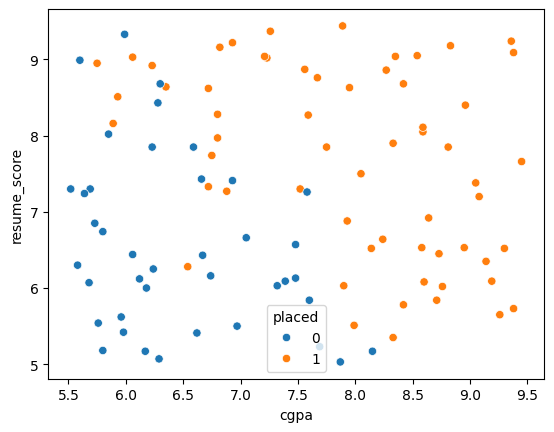

In [5]:
sns.scatterplot(x=df["cgpa"], y=df["resume_score"], hue=df["placed"])

In [20]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [21]:
from sklearn.linear_model import Perceptron

In [22]:
p=Perceptron()

In [23]:
p.fit(X,y)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",1.0
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


In [24]:
p.coef_   #attribute inside the perceptron for get the output (ITS WEIGHTS W1,W2)

array([[ 9.8, 13. ]])

In [25]:
p.intercept_ #this is a bias

array([-69.])

In [26]:
pip install mlxtend

Note: you may need to restart the kernel to use updated packages.


In [33]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

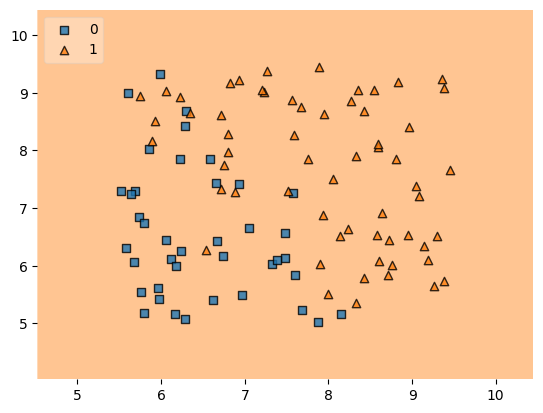

In [34]:
plot_decision_regions(X.values,y.values,clf=p,legend=2)

# Algorithm

In [36]:
from sklearn.datasets import make_classification #for create classification data
import numpy as np

In [ ]:
X,y = make_classification(n_samples=100,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=41,hypercube=False,class_sep=10)

In [45]:
X,y

(array([[ 0.19924745, -0.11697552],
        [-0.24882029, -0.73115232],
        [-0.3544904 , -0.7081059 ],
        [-1.59086506, -2.01199214],
        [-0.20083951,  1.63493163],
        [-0.83241122,  0.15599044],
        [-1.79207014,  1.07782053],
        [ 0.0856607 ,  0.80626713],
        [-0.55865299,  0.74859527],
        [-1.95974262,  0.75152794],
        [-1.77828947, -0.90114581],
        [-1.77985853, -0.1815243 ],
        [-0.02194151, -2.98092432],
        [ 0.80563431,  1.20500136],
        [-1.82701214,  0.78302407],
        [ 0.38730728,  0.42968688],
        [-0.14108668, -0.73229726],
        [-1.87955941, -0.83930476],
        [-0.18232911,  0.83727062],
        [-1.77059533, -0.10255323],
        [-2.27658028,  0.65867001],
        [-2.06519502,  0.92649819],
        [-1.31690551,  0.10216193],
        [ 1.61043259,  0.46886454],
        [-1.21650394,  0.45432938],
        [ 0.6139723 ,  1.8613386 ],
        [-1.78760957, -0.79255991],
        [-1.04149161, -1.000

In [ ]:
import matplotlib.pyplot as plt

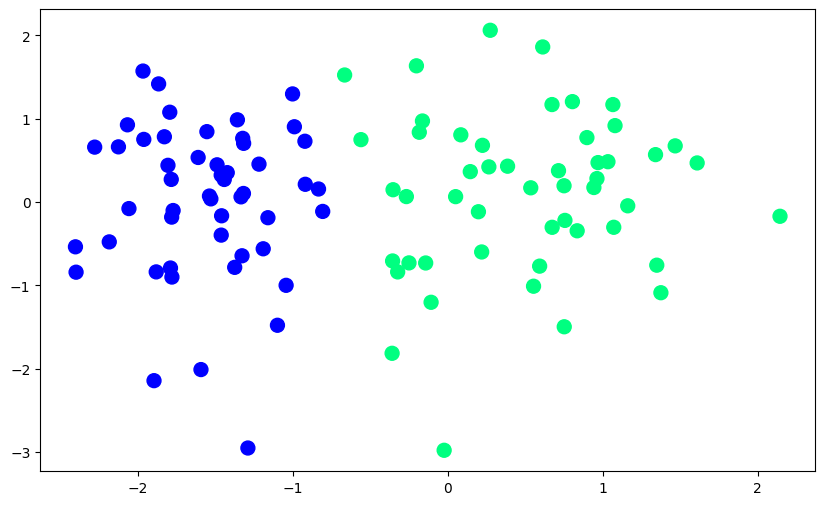

In [42]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap="winter",s=100)

In [67]:
def perceptron(X,y):
    x= np.insert(X,0,1,axis=1)
    weights=np.ones(X.shape[1])
    lr=0.1

    for i in range(1000):
        j=np.random.randint(0,1000)
        y_hat= step(np.dot(x[j],weights))
        weights= weights+ lr*([j]-y_hat)*x[j]

    return weights[0],weights[1:]
        

In [68]:
def step(z):
    return 1 if z>0 else 0

In [69]:
intercept_,coef_=perceptron(X,y)

IndexError: index 421 is out of bounds for axis 0 with size 100

In [72]:
import numpy as np


# The step function needs to be defined outside or before it's called
def step(z):
    return 1 if z >= 0 else 0


def perceptron(X, y):
    # 1. Properly insert the bias column of 1s at index 0
    x = np.insert(X, 0, 1, axis=1)

    # 2. Initialize weights to match the new shape (3 weights: 1 bias + 2 features)
    weights = np.ones(x.shape[1])
    lr = 0.1

    for i in range(1000):
        # 3. Pick a random index based on actual data length (0 to 99)
        j = np.random.randint(0, x.shape[0])

        # 4. Use 'x' (with bias) consistently
        y_hat = step(np.dot(x[j], weights))

        # 5. Correct the formula to use the actual label y[j] instead of index j
        weights = weights + lr * (y[j] - y_hat) * x[j]

    # 6. Return intercept (bias weight) and coefficients (feature weights) separately
    return weights[0], weights[1:]


# Run it on your make_classification data
intercept_, coef_ = perceptron(X, y)

print("Intercept_:", intercept_)
print("Coef_:", coef_)

Intercept_: 0.9
Coef_: [1.31036291 0.09575185]


array([1., 1.])